### - it is used in the situation in which the output depends on the  future  output like in the case of Amazon
- I love amazon it is a great river
- I love amazon it  is a great website
- It has two RNN
- - first is the forward RNN and the second is the backward RNN and we merge the output of both the RNN

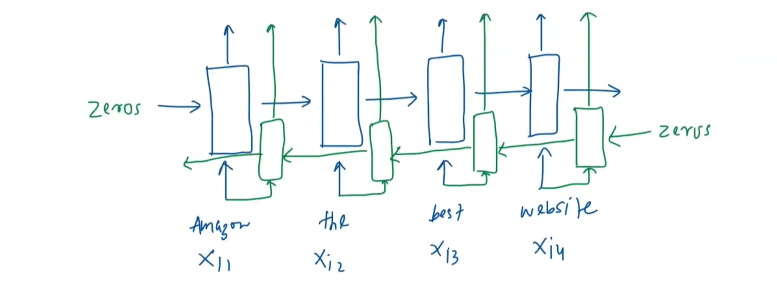

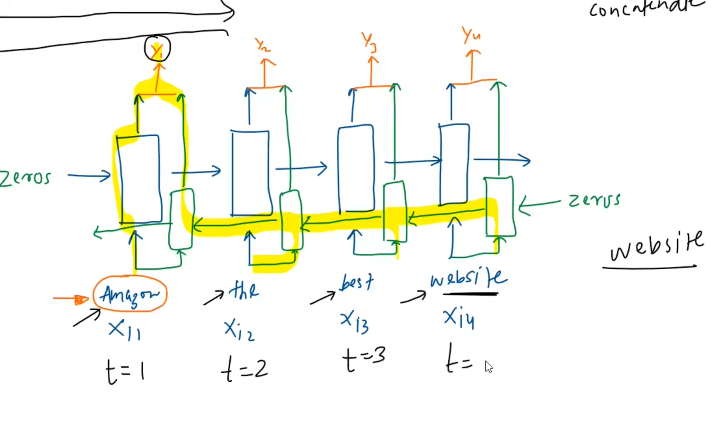

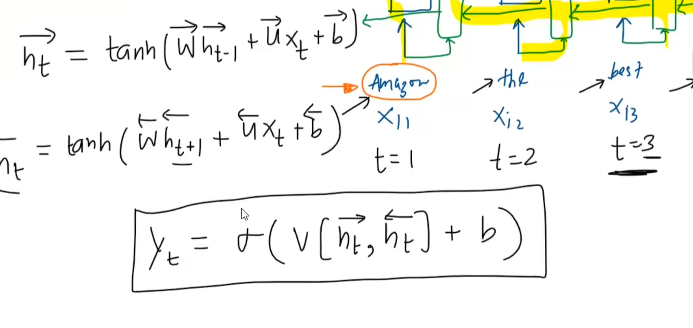

#### Using IMDB Dataset

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,Bidirectional,SimpleRNN,Input
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
num_words =1000
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=num_words)
maxlen=200
X_train = pad_sequences(X_train,maxlen=maxlen,padding='post',truncating='post')
X_test = pad_sequences(X_test,maxlen=maxlen,padding='post',truncating='post')
embedding_dim=32
model = Sequential([
    Input(shape=(200,), dtype="int32"),
    Embedding(input_dim=num_words,output_dim=embedding_dim,input_length=maxlen),
    SimpleRNN(5),
    Dense(1,activation='sigmoid')
]) # binary classification positive or negative 


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 5)              │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,196 (125.77 KB)

 Trainable params: 32,196 (125.77 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.fit(X_train,y_train,epochs=30,validation_data=(X_test,y_test))

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.5216 - loss: 0.6908 - val_accuracy: 0.5089 - val_loss: 0.6952
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.5642 - loss: 0.6763 - val_accuracy: 0.4970 - val_loss: 0.7027
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.5869 - loss: 0.6601 - val_accuracy: 0.4971 - val_loss: 0.7130
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.6063 - loss: 0.6452 - val_accuracy: 0.5056 - val_loss: 0.7263
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.6190 - loss: 0.6323 - val_accuracy: 0.5013 - val_loss: 0.7422
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.6294 - loss: 0.6206 - val_accuracy: 0.4986 - val_loss: 0.7570
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.6374 - loss: 0.6119 - val_accuracy: 0.5097 - val_loss: 0.7693
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.6478 - loss: 0.6037 - 

### Bidirectional RNN

In [ ]:
num_words =1000
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=num_words)
maxlen=200
X_train = pad_sequences(X_train,maxlen=maxlen,padding='post',truncating='post')
X_test = pad_sequences(X_test,maxlen=maxlen,padding='post',truncating='post')
embedding_dim=32
model = Sequential([
    Input(shape=(200,), dtype="int32"),
    Embedding(input_dim=num_words,output_dim=embedding_dim,input_length=maxlen),
    Bidirectional(5),
    Dense(1,activation='sigmoid')
]) # binary classification positive or negative 


In [22]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [23]:
model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10


I0000 00:00:1790337685.703161    6734 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_1_while_body_68563_grad_68792_const_0__.17.clone.clone.clone.clone.clone.clone.clone


781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6137 - loss: 0.6151

I0000 00:00:1790337713.499031    6734 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_1_while_body_68563_grad_68792_const_0__.17.clone.clone.clone.clone.clone.clone.clone


782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.6136 - loss: 0.6152 - val_accuracy: 0.5227 - val_loss: 0.7273
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.6817 - loss: 0.5824 - val_accuracy: 0.6380 - val_loss: 0.6760
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.7072 - loss: 0.5824 - val_accuracy: 0.5189 - val_loss: 0.7483
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.5772 - loss: 0.6547 - val_accuracy: 0.5245 - val_loss: 0.7138
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6043 - loss: 0.6369 - val_accuracy: 0.5087 - val_loss: 0.7121
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.6285 - loss: 0.6192 - val_accuracy: 0.5693 - val_loss: 0.7061
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.6660 - loss: 0.5923 - val_accuracy: 0.6253 - val_loss: 0.6850
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.6486 - loss: 0.6320 - val_accurac

Use of the Bidirectional RNN
- Named Entity Reconition
- Part of Speech tagging
- Machine translation
- Sentiment Analysis
- Time Series Forcasting

## Drawback
- Complexity
- there might be the cases in which we dont have the data 